In [1]:
# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Quantmod
import quantmod.charts
from quantmod.datasets import fetch_historical_data
from quantmod.timeseries import OpCl, HiLo, Gap, dailyReturn, lag, lead
from quantmod.indicators import SMA, BBands
from quantmod.markets import getData, getTicker

# scikit-learn
import sklearn

# Data Preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler   #RobustScaler: (X-Median)/IQR(四分位距） 
from sklearn.compose import ColumnTransformer ## allow us to use different scaler for different columns, as different column may have different data type, or magnitude
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Wrapper Feature Selection
from sklearn.feature_selection import SequentialFeatureSelector

# Classifier
from sklearn.svm import LinearSVC
from sklearn.svm import SVC

# Hyperparameter Tuning
from sklearn.model_selection import TimeSeriesSplit,GridSearchCV

# Metrics
from sklearn.metrics import (
                            accuracy_score,
                            RocCurveDisplay,
                            ConfusionMatrixDisplay,
                            classification_report
                            )

import warnings
warnings.filterwarnings('ignore')
import pyfolio as pf   ## to run pyfolio, I have downgraded pandas and numpy. 

### Step 0.1. Load Data

In [1]:
## get around 5 year data for Coca Cola (KO)
Data = getData("KO", start_date="2020-01-01", end_date="2025-10-09")
Data

NameError: name 'getData' is not defined

In [4]:
## get around 5 year data for SPY. Will add their return as features to predict daily return of KO
SPY = getData("SPY", start_date="2020-01-01", end_date="2025-10-09")

### Step 0.2. EDA of Original Dataset

In [5]:
# get info
Data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1450 entries, 2020-01-02 to 2025-10-08
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1450 non-null   float64
 1   High    1450 non-null   float64
 2   Low     1450 non-null   float64
 3   Close   1450 non-null   float64
 4   Volume  1450 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 68.0 KB


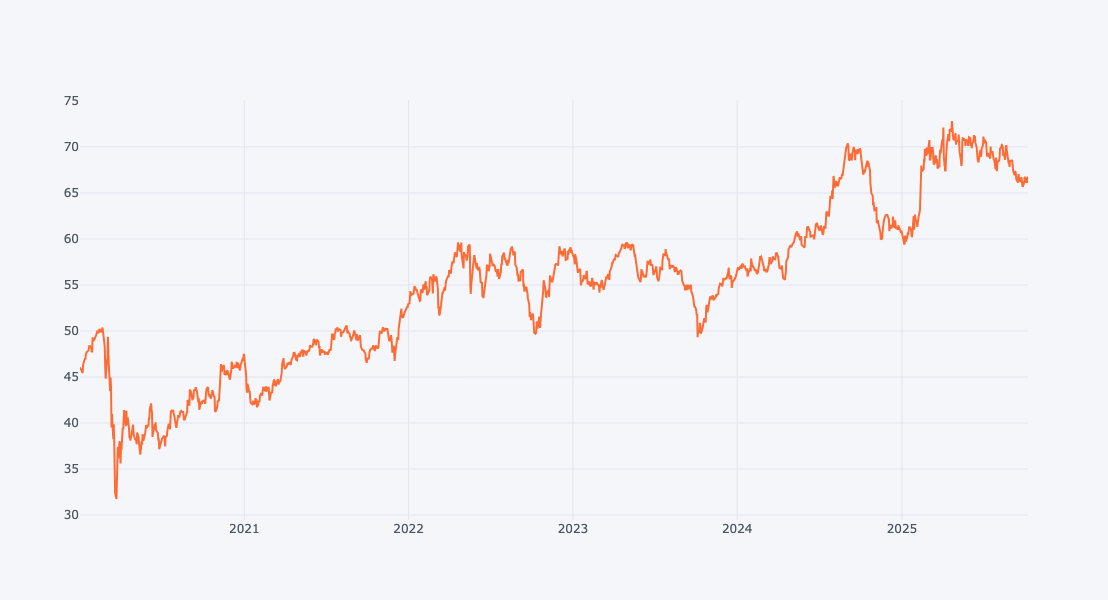

In [6]:
# Visualize data
Data.Close.iplot(kind="line")

In [7]:
Data.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,1450.0,5.467882e+01,8.743337e+00,3.275492e+01,4.803285e+01,5.562685e+01,5.946650e+01,7.230741e+01
High,1450.0,5.507548e+01,8.764741e+00,3.286478e+01,4.831881e+01,5.600154e+01,5.973702e+01,7.329280e+01
Low,1450.0,5.425179e+01,8.734164e+00,3.065070e+01,4.777005e+01,5.522342e+01,5.899563e+01,7.185414e+01
Close,1450.0,5.467082e+01,8.769861e+00,3.174084e+01,4.799734e+01,5.562533e+01,5.938604e+01,7.281982e+01
Volume,1450.0,1.552093e+07,6.675060e+06,3.265500e+06,1.156278e+07,1.401360e+07,1.746042e+07,6.784570e+07


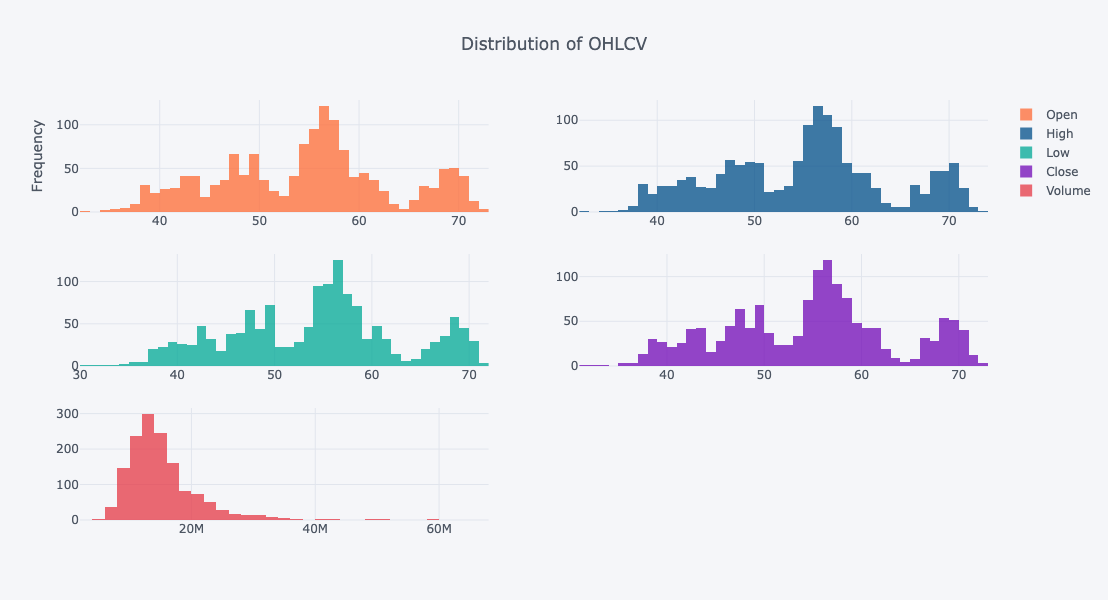

In [8]:
# Histogram
(Data/100).iplot(
    kind="histogram",
    overlap=False,
    showlegend=True,
    title="Distribution of OHLCV"
    )

In the distribution plot of the OHLCV data, I observeed one major peak and several other smaller peaks, indicating significant variability across different value ranges. Additionally, the volume data appears to be right-skewed.

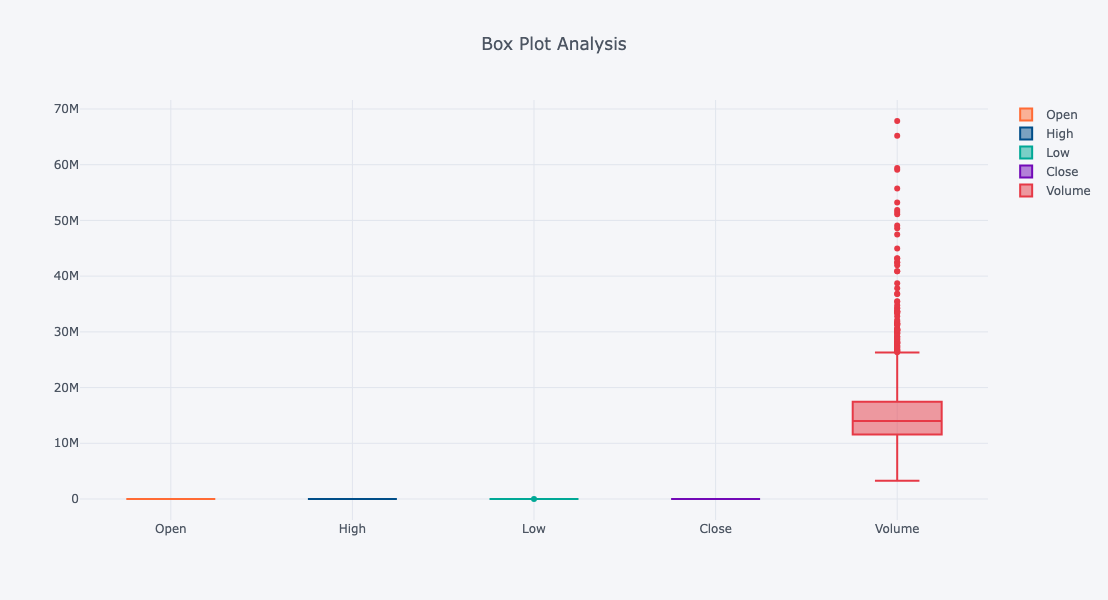

In [9]:
# Box Plot
Data.iplot(
    kind="box",
    showlegend=True,
    title="Box Plot Analysis"
    )

The boxplots suggest that outliers are present only in the Volume column, whereas the other columns do not show any visible outliers.

### Step 0.3. Cleaning & Imputation

In [10]:
Data.isnull().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Data is already cleaned. No further processing or imputation required.

# Step 1 Math question on Gaussian RBF kernel

RBF kernel centers on measuring the "similarity" between two points as a function of their distance. $\parallel X{i} - X{j} \parallel ^{2}$ is the squared Euclidean distance between the two points. This is a measure of how far apart they are. The $-1/2\sigma^2$ is actually the $\gamma$, which is a hyperparameter that controls the "width" or "reach" of the kernel.

The result is a similarity score between 0 and 1. If the points are identical, the distance is 0, and the kernel value is exp(0)=1. As the points get farther apart, the kernel value decays towards 0.

Thus, the correct answer is (a). k(z1; x) will be close to 1 and k(z2; x) will be close to 0. As z1 and x are close to each other, their Euclidean distance will close to 0, thus the kernel value will close to 1. Similarly, as z2 and x are far away from each other, their Euclidean distance will become very large, thus the kernel value will close to 0.

# Step 2 What are voting classiers in ensemble learning?

A voting classifier is an ensemble learning method that combines the predictions from multiple different machine learning models (for example can include logistic regression, svm, decision tree) to make a final, often more accurate, prediction.

The core idea is that by combining the "opinions" of several models, the final decision will be more robust and less prone to the errors of any single model. Think of it like asking a group of diverse experts for their opinion instead of relying on just one.

There are two major voting types: hard voting and soft voting. Hard voting is a simple majority vote based on each model's prediction output. Soft voting is a more nuanced approach where each model's prediction is weighted by its predicted probability. The final prediction is the class with the highest average probability across all models. 

# Step 3 Feature Selection Using the Funnelling Approach

## Step 3.1. Create features

In [11]:
def create_features(frame,frame2):
    df = frame.copy()
    df2 = frame2.copy()
    
    multiplier = 2

    # Features - X
    df['OC'] = OpCl(df)
    df['HC'] = HiLo(df)
    df['GAP'] = Gap(df)
    df['RET'] = dailyReturn(df.Close)
    df2['RET'] = dailyReturn(df2.Close)

    for i in [7, 14, 28]:
        df['PCHG' + str(i)] = df['Close'].pct_change(i)
        df['VCHG' + str(i)] = df['Volume'].pct_change(i)
        df['RET' + str(i)] = df['RET'].rolling(i).sum()
        
        df['SPY_RET' + str(i)] = df2['RET'].rolling(i).sum()

        df['OC'+ str(i)] = df['OC'].rolling(i).mean()
        df['HC'+ str(i)] = df['HC'].rolling(i).mean()
        df['GAP'+ str(i)] = df['GAP'].rolling(i).mean()
        df['STD'+ str(i)] = df['RET'].rolling(i).std()
        df['LB'+str(i)] = BBands(df['Close'], i, multiplier)[0]  #布林带（Bollinger Bands) lower band
        df['UB'+str(i)] = BBands(df['Close'], i, multiplier)[2]  #upper band

    # Extra Features
    # 1. Moving Average Ratio
    df['SMA_10'] = df['Close'].rolling(window=10).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()
    df['MA_Ratio'] = df['SMA_10'] / df['SMA_50']
    
    # 2. Relative Strength Index (RSI)
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).ewm(com=13, adjust=False).mean()  # ewm: expotential weighted moving average: recent date has more impact
    loss = (-delta.where(delta < 0, 0)).ewm(com=13, adjust=False).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # 3. Stochastic Oscillator (%K)
    low_14 = df['Low'].rolling(window=14).min()
    high_14 = df['High'].rolling(window=14).max()
    df['Stochastic_K'] = 100 * ((df['Close'] - low_14) / (high_14 - low_14))

    # 4. Bollinger Band Width
    sma_20 = df['Close'].rolling(window=20).mean()
    std_20 = df['Close'].rolling(window=20).std()
    upper_band = sma_20 + (2 * std_20)
    lower_band = sma_20 - (2 * std_20)
    df['Bollinger_Width'] = (upper_band - lower_band) / sma_20

    # 5. Average True Range (ATR)
    high_low = df['High'] - df['Low']
    high_prev_close = np.abs(df['High'] - df['Close'].shift())
    low_prev_close = np.abs(df['Low'] - df['Close'].shift())
    true_range = pd.concat([high_low, high_prev_close, low_prev_close], axis=1).max(axis=1)
    df['ATR'] = true_range.ewm(span=14, adjust=False).mean()

    # 6. On-Balance Volume (OBV)
    df['OBV'] = (np.sign(df['Close'].diff()) * df['Volume']).fillna(0).cumsum()

    # 7. Intraday Intensity
    # Handle division by zero for days where High == Low
    denominator = (df['High'] - df['Low'])
    # Replace 0s with a small number to avoid errors, result will be 0 anyway if numerator is 0
    denominator = denominator.replace(0, 1e-9) 
    df['Intraday_Intensity'] = (2 * df['Close'] - df['High'] - df['Low']) / denominator * df['Volume']

    # Define the label - y
    df['Label'] = np.where(lead(df['RET']) > 0.0025, 1, 0)  # assign 1 if next day's return > 0.25%

    # Drop unnecessary columns
    df.drop(['Open', 'High', 'Low', 'Close', 'Volume'], axis=1, inplace=True)
    df.dropna(inplace=True)

    return df

# get df
df = create_features(Data,SPY)
display(df.shape)
# Verify the output
df.head(2)


(1401, 44)

,OC,HC,GAP,RET,PCHG7,VCHG7,RET7,SPY_RET7,OC7,HC7,...,SMA_10,SMA_50,MA_Ratio,RSI,Stochastic_K,Bollinger_Width,ATR,OBV,Intraday_Intensity,Label
Date,,,,,,,,,,,,,,,,,,,,,
2020-03-13,0.878871,2.492958,0.059037,0.036131,-0.170145,0.641676,-0.186504,-0.149856,0.366099,1.958583,...,44.959364,47.524803,0.946019,33.714530,17.626542,0.268978,2.340610,12439700.0,8.795543e+06,0
2020-03-16,-2.552109,5.670424,-0.128533,-0.068521,-0.195331,0.598033,-0.217324,-0.231935,-0.125343,2.531687,...,44.099604,47.368433,0.930991,28.947739,23.618324,0.309814,2.851063,-16242600.0,6.283590e+06,1


In [12]:
# get y
y = np.array(df['Label'])
y

array([0, 1, 0, ..., 1, 0, 0])

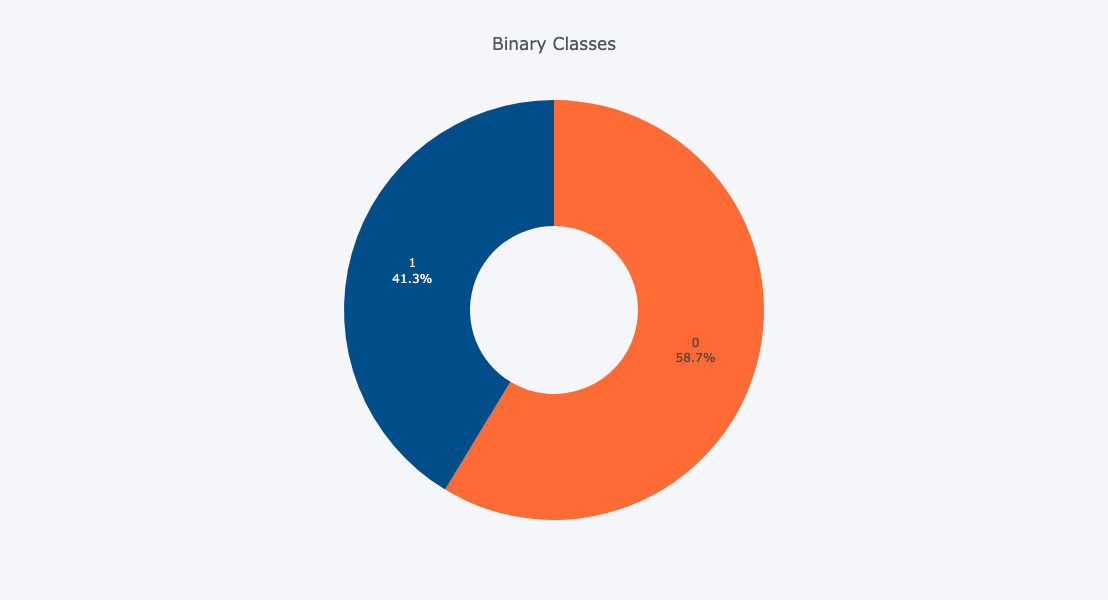

In [13]:
df['Label'].value_counts().iplot(kind='pie', title='Binary Classes')

I observed the class are relatively imbalanced through the lables, so when train the SVC model, I will let the class_weight='balanced'. 

## Step 3.2. Feature Selection

As we know, there are three methods for feature selection: filter, wrapper, and embedded methods. I will use the funneling approach by combining all three methods and running the features through them one by one to get a final list of features for model training. Specifically, I will use correlation based feature selection for the filter memthod, SFS+SVC for the wrapper method, and LinearSVC for the embedded method. 

Here is a brief summary of the three methods: 

Filter methods: select features based on their intrinsic statistical properties and their relationship with the target variable, independent of any machine learning model. Features are ranked using statistical tests like correlation coefficients, Chi-squared tests, or ANOVA F-tests. Then, select the top-ranking features. The filder method is very fast and computationally inexpensive, but they ignore feature interactions and how the features will perform with a specific model, which can lead to a suboptimal feature subset.

Wrapper methods: use a specific machine learning model to evaluate the usefulness of a subset of features. They "wrap" the feature selection process around the model. A model is trained and evaluated repeatedly on different subsets of features. Common examples include Recursive Feature Elimination (RFE) and Sequential Forward Selection (SFS). This method often results in the best-performing feature subset for the chosen model because they account for feature interactions and model-specific behavior. However, this method is very slow and computationally expensive, as they require training a model multiple times.

Embedded methods: perform feature selection as an integral part of the model training process. The selection is "embedded" within the model itself. The model's algorithm inherently assigns importance scores or coefficients to features, effectively selecting them. The most common example is Lasso (L1) regularization, which forces the coefficients of unimportant features to become exactly zero. They are a good compromise between the speed of filter methods and the accuracy of wrapper methods. They are also less prone to overfitting than wrapper methods. However, the feature selection is tied to a specific model; the selected features might not be optimal for a different type of model.

### Step 3.2.1 Filter method: 

#### Justification:
The filter method I use is Correlation-based Feature Selection (CFS). Here I calculated correlation matrix, and removed the features with high correlation. The main benefit of using correlation-based feature selection is its simplicity and effectiveness in improving a model by removing redundant and irrelevant features. This method is also faster than wrapper method.

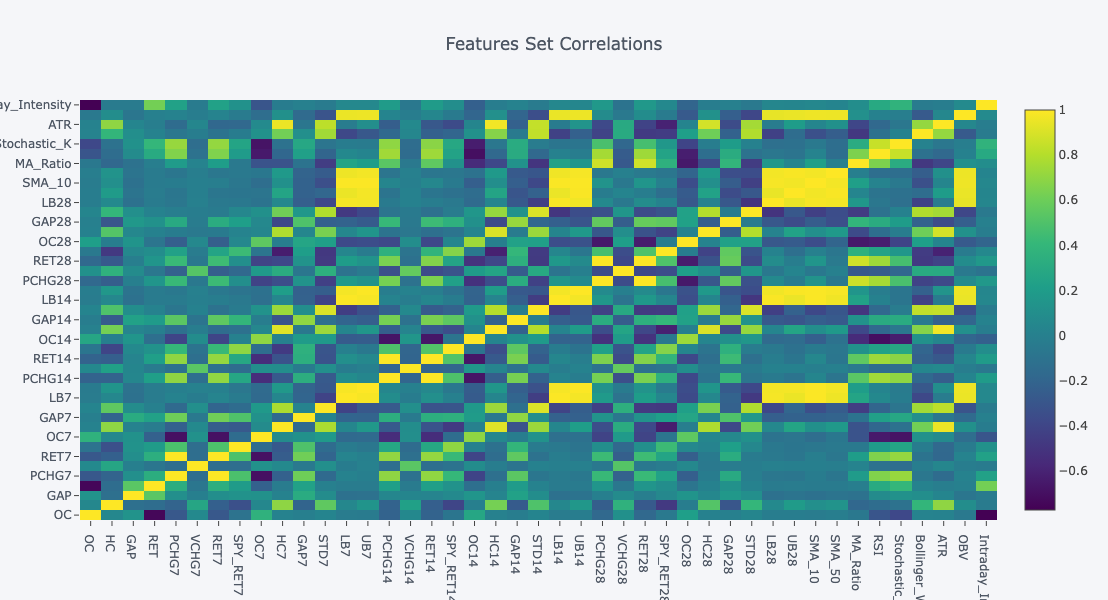

In [14]:
# Drop label from dataframe
df.drop('Label', axis=1, inplace=True)

# Plot correlation matrix
df.corr().iplot(
    kind="heatmap",
    title="Features Set Correlations"
    )

In [15]:
# Remove highly correlated features - abs cor greater than 0.90 in this case
threshold = 0.9
corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns to drop
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

# Number of features dropped
print(f"\n No. of features dropped: {len(to_drop)} \n List of features dropped: {to_drop}")


 No. of features dropped: 16 
 List of features dropped: ['RET7', 'UB7', 'RET14', 'HC14', 'STD14', 'LB14', 'UB14', 'RET28', 'HC28', 'STD28', 'LB28', 'UB28', 'SMA_10', 'SMA_50', 'ATR', 'OBV']


In [16]:
# Drop the highly correlated features
X = df.drop(to_drop, axis=1)

# Remaining Record feature names
feature_names = X.columns
feature_names
print(f"\n Remaining {len(feature_names)} features after Filter method: {feature_names}")


 Remaining 27 features after Filter method: Index(['OC', 'HC', 'GAP', 'RET', 'PCHG7', 'VCHG7', 'SPY_RET7', 'OC7', 'HC7',
       'GAP7', 'STD7', 'LB7', 'PCHG14', 'VCHG14', 'SPY_RET14', 'OC14', 'GAP14',
       'PCHG28', 'VCHG28', 'SPY_RET28', 'OC28', 'GAP28', 'MA_Ratio', 'RSI',
       'Stochastic_K', 'Bollinger_Width', 'Intraday_Intensity'],
      dtype='object')


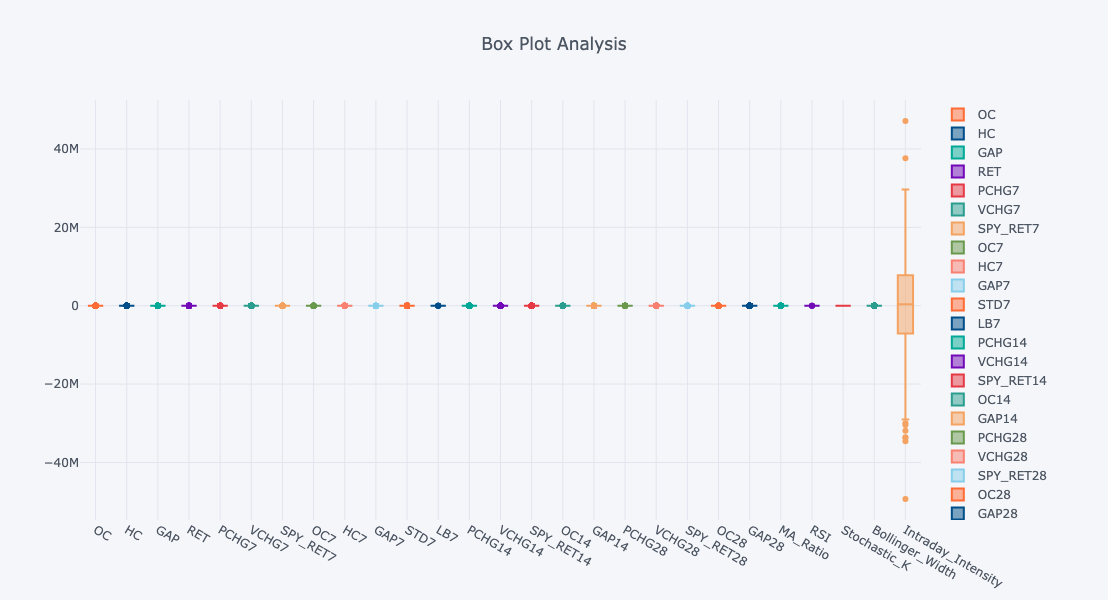

In [17]:
# Study distribution
X.iplot(
    kind="box",
    showlegend=True,
    title="Box Plot Analysis",
    )

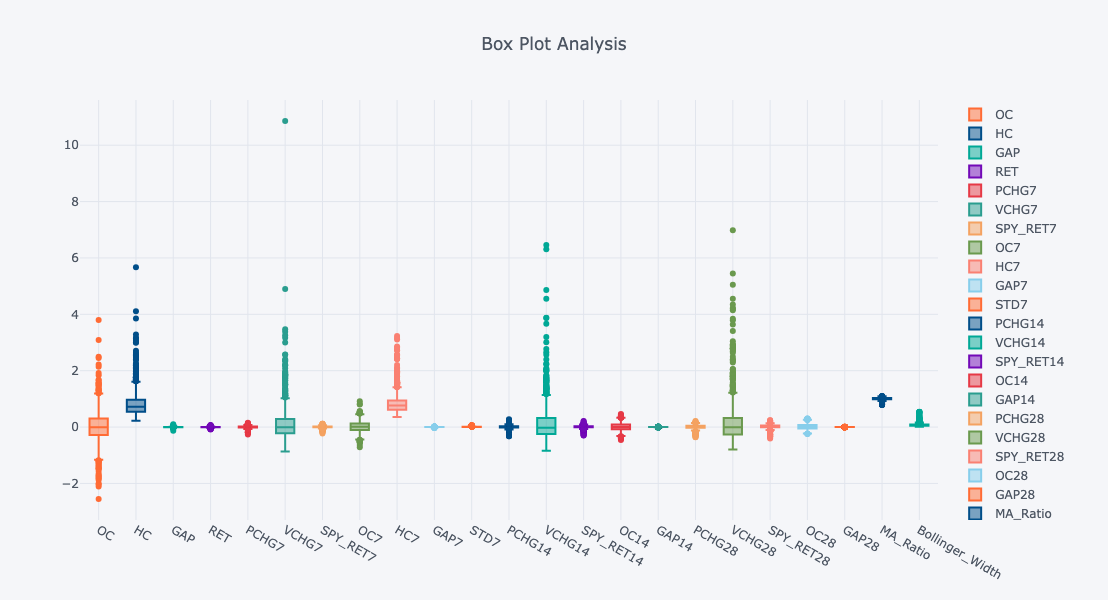

In [18]:
# Study distribution without outlier features
X.drop(['LB7','Intraday_Intensity','RSI','Stochastic_K'], axis=1).iplot(
    kind="box",
    showlegend=True,
    title="Box Plot Analysis",
    )

### Step 3.2.2 Wrapper method: 

#### Justification:
I used forward selecion on SVC to further select features. As I'm going to use the SVM model to predict the return later, I used SVM to be the base model here for the forward feature selection. I used the most naive version without any complicated hyperparameters. 

Forward selection will begin with zero features. Then, it will iteratively test each individual feature. Train the model on each and select the one that gives the best performance (e.g., highest accuracy or lowest error). It will keep the best feature, then test all remaining features one by one, adding each to your selected set. Keep the one that gives the biggest additional boost in performance. It will continue this process until adding a new feature provides no significant improvement.

The main benefit of forward selection is the Model-Specific Optimization. The features are selected based on their actual contribution to the performance of the specific model (e.t., a Random Forest). This is far more relevant than using a generic statistical filter.

It also captures Feature Interactions as it adds features one by one, it can capture some interaction effects, whereas a filter method that only looks at features individually.

In [19]:
# Splitting the datasets into training and testing data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False) 
# Output the train and test data size
print(f"Train and Test Size {len(X_train)}, {len(X_test)}")

Train and Test Size 1120, 281


In [20]:
# Extract Features for Scaling
feature_names = X.columns
outlier_feature = ['LB7','OC', 'HC','VCHG7', 'OC7','HC7','PCHG14','VCHG14','SPY_RET14','OC14','PCHG28','VCHG28','SPY_RET28','OC28','Intraday_Intensity','MA_Ratio','RSI','Stochastic_K','Bollinger_Width']  ## based on the box plot, we will use Robust Scaler for these features
other_features = [col for col in feature_names if col not in outlier_feature]  ## use standard scaler for the rest features

In [21]:
# Define pipeline with ColumnTransformer and SequentialFeatureSelector
sfs = Pipeline(steps=[
    ('scaling', ColumnTransformer(
        transformers=[
            ('robust', RobustScaler(), outlier_feature),
            ('standard', StandardScaler(), other_features)
        ])),
    ('sfs', SequentialFeatureSelector(SVC(kernel='rbf',class_weight='balanced')))  ## 'rbf' is best for financial data
])

# Fit SFS to the training data
sfs.fit(X_train, y_train)


,steps,"[('scaling', ...), ('sfs', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('robust', ...), ('standard', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
selected_feature_names = (
    sfs.named_steps['sfs']
    .get_support()            #view transformed column names
)

print(f"\n Remaining {len(X.columns[selected_feature_names])} features after Wrapper method: {X.columns[selected_feature_names]}")


 Remaining 13 features after Wrapper method: Index(['GAP', 'RET', 'PCHG7', 'SPY_RET7', 'OC7', 'LB7', 'SPY_RET14', 'PCHG28',
       'OC28', 'GAP28', 'MA_Ratio', 'Stochastic_K', 'Bollinger_Width'],
      dtype='object')


In [23]:
# Dataset with the remaining features
X = X.iloc[:,selected_feature_names]
X

,GAP,RET,PCHG7,SPY_RET7,OC7,LB7,SPY_RET14,PCHG28,OC28,GAP28,MA_Ratio,Stochastic_K,Bollinger_Width
Date,,,,,,,,,,,,,
2020-03-13,0.059037,0.036131,-0.170145,-0.149856,0.366099,38.113101,-0.179955,-0.165328,0.052631,-0.004775,0.946019,17.626542,0.268978
2020-03-16,-0.128533,-0.068521,-0.195331,-0.231935,-0.125343,36.549136,-0.265070,-0.224049,-0.035823,-0.009469,0.930991,23.618324,0.309814
2020-03-17,0.013699,0.041547,-0.138730,-0.162681,-0.243989,36.485453,-0.208801,-0.191270,-0.076555,-0.009016,0.918324,34.705685,0.327295
2020-03-18,-0.051717,-0.050647,-0.127587,-0.133328,-0.280006,35.365473,-0.214809,-0.233034,-0.079575,-0.010942,0.897074,21.250700,0.353033
2020-03-19,-0.010925,-0.069709,-0.213625,-0.181656,0.078083,34.110583,-0.208476,-0.287095,0.006057,-0.011266,0.874955,4.527991,0.393494
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-02,-0.003744,-0.010235,-0.009144,0.009021,0.095715,65.471390,0.020574,-0.050236,0.123506,-0.000014,0.975342,42.134860,0.029985
2025-10-03,0.000000,0.008286,0.003010,0.012193,0.022857,65.438804,0.015249,-0.025662,0.062041,-0.000004,0.976219,73.033929,0.027354
2025-10-06,-0.002401,-0.008286,0.001819,0.020397,-0.031429,65.475501,0.020207,-0.030890,0.064982,-0.000147,0.976789,42.134860,0.027337


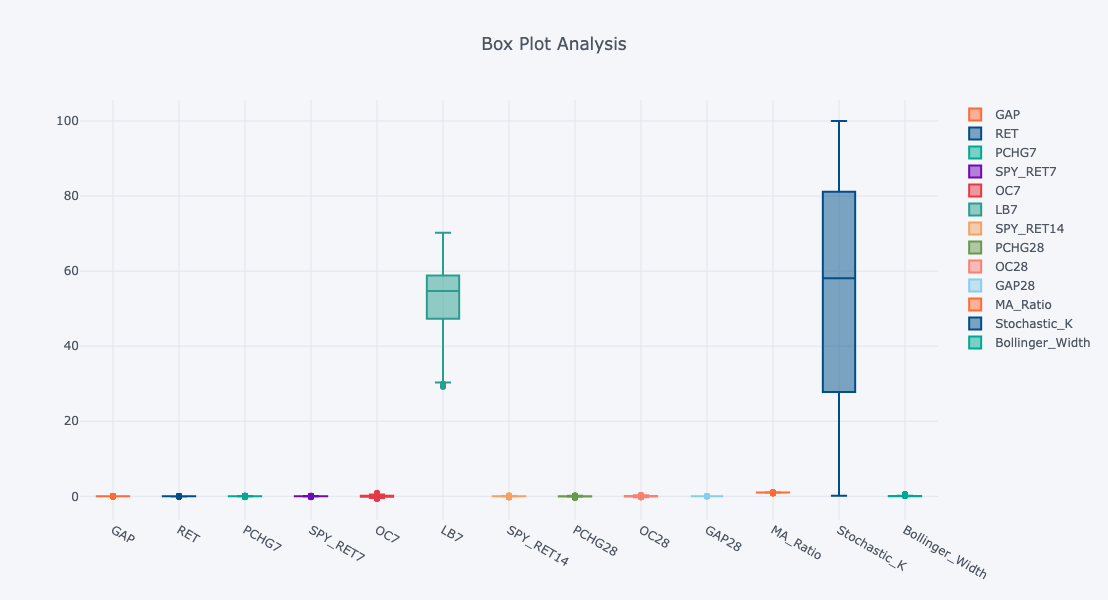

In [24]:
# Study distribution
X.iplot(
    kind="box",
    showlegend=True,
    title="Box Plot Analysis",
    )

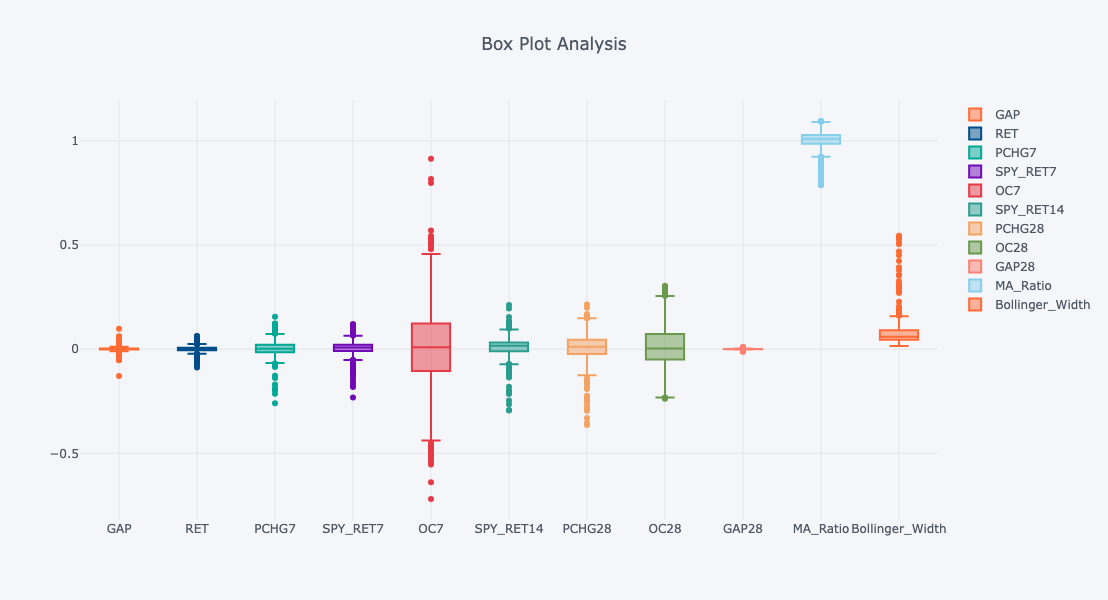

In [25]:
# Study distribution without outlier features
X.drop(['LB7','Stochastic_K'], axis=1).iplot(
    kind="box",
    showlegend=True,
    title="Box Plot Analysis",
    )

### Step 3.2.3 Embedded method: 

#### Justification:
For this step, I will use LinearSVC. LinearSVC, when used with an L1 penalty (penalty='l1'), is a classic embedded feature selection method.

By using LinearSVC(penalty='l1'), we are forcing the model to identify the smallest subset of features that are most predictive. Any feature assigned a coefficient of zero is considered irrelevant and can be safely discarded, simplifying our dataset.

In [26]:
# Splitting the datasets into training and testing data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False) 
# Output the train and test data size
print(f"Train and Test Size {len(X_train)}, {len(X_test)}")

Train and Test Size 1120, 281


In [27]:
# Extract Features for Scaling
feature_names = X.columns
outlier_feature = ['LB7','GAP','RET','PCHG7','SPY_RET7','OC7','SPY_RET14','PCHG28','OC28','GAP28','MA_Ratio','Stochastic_K','Bollinger_Width']  ## based on the box plot, we will use Robust Scaler for these features
other_features = [col for col in feature_names if col not in outlier_feature]  ## use standard scaler for the rest features

In [28]:
# Define pipeline with ColumnTransformer and LinearSVC
linearsvc = Pipeline(steps=[
    ('scaling', ColumnTransformer(
        transformers=[
            ('robust', RobustScaler(), outlier_feature),
            ('standard', StandardScaler(), other_features)
        ])),
    ('classifier', LinearSVC(penalty='l1', C=0.05, dual=False, max_iter=50000,class_weight='balanced'))

])

# Train the model
linearsvc.fit(X_train, y_train)

,steps,"[('scaling', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('robust', ...), ('standard', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
feature_coefficients = (
    linearsvc.named_steps['classifier']
    .coef_            #view transformed column names
)

feature_names = (
    linearsvc.named_steps['scaling']
    .get_feature_names_out()            #view transformed column names
)

selected_feature_names = []
for i in range(len(feature_names)):
    if feature_coefficients[0][i] != 0:
        if feature_names[i][:7] == 'robust_':
            feature_name = feature_names[i][8:]
        else:
            feature_name = feature_names[i][10:]
        selected_feature_names.append(feature_name)
        
print(f"\n Remaining {len(selected_feature_names)} features after Embedded method: {selected_feature_names}")


 Remaining 9 features after Embedded method: ['LB7', 'GAP', 'RET', 'OC7', 'SPY_RET14', 'OC28', 'GAP28', 'MA_Ratio', 'Bollinger_Width']


In [30]:
# Dataset with the remaining features
X = X.loc[:,selected_feature_names]
X

,LB7,GAP,RET,OC7,SPY_RET14,OC28,GAP28,MA_Ratio,Bollinger_Width
Date,,,,,,,,,
2020-03-13,38.113101,0.059037,0.036131,0.366099,-0.179955,0.052631,-0.004775,0.946019,0.268978
2020-03-16,36.549136,-0.128533,-0.068521,-0.125343,-0.265070,-0.035823,-0.009469,0.930991,0.309814
2020-03-17,36.485453,0.013699,0.041547,-0.243989,-0.208801,-0.076555,-0.009016,0.918324,0.327295
2020-03-18,35.365473,-0.051717,-0.050647,-0.280006,-0.214809,-0.079575,-0.010942,0.897074,0.353033
2020-03-19,34.110583,-0.010925,-0.069709,0.078083,-0.208476,0.006057,-0.011266,0.874955,0.393494
...,...,...,...,...,...,...,...,...,...
2025-10-02,65.471390,-0.003744,-0.010235,0.095715,0.020574,0.123506,-0.000014,0.975342,0.029985
2025-10-03,65.438804,0.000000,0.008286,0.022857,0.015249,0.062041,-0.000004,0.976219,0.027354
2025-10-06,65.475501,-0.002401,-0.008286,-0.031429,0.020207,0.064982,-0.000147,0.976789,0.027337


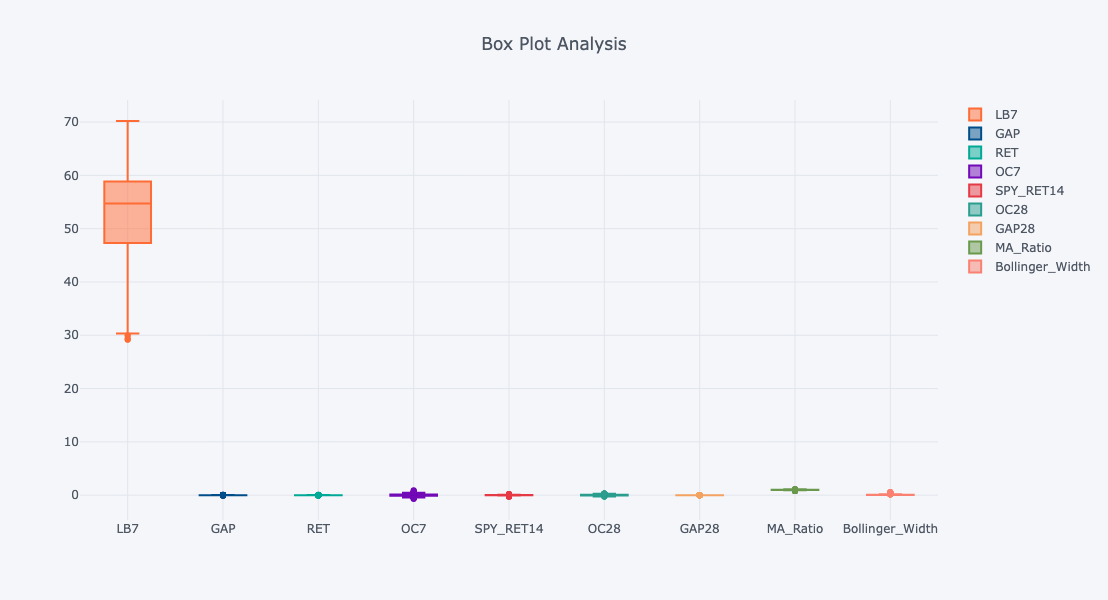

In [31]:
# Study distribution
X.iplot(
    kind="box",
    showlegend=True,
    title="Box Plot Analysis",
    )

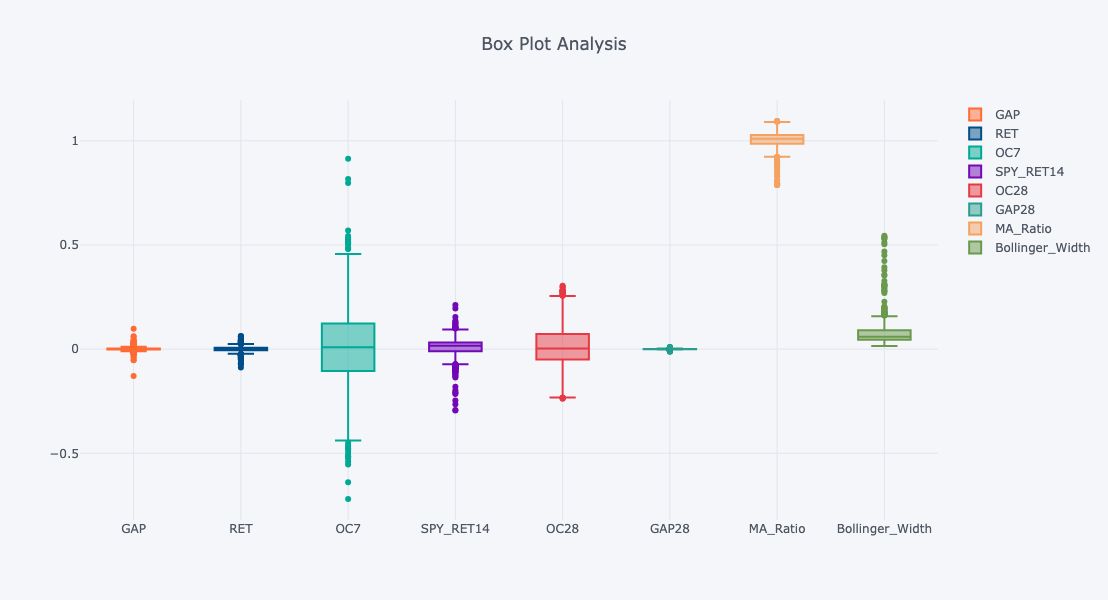

In [32]:
# Study distribution without LB7
X.drop(['LB7'], axis=1).iplot(
    kind="box",
    showlegend=True,
    title="Box Plot Analysis",
    )

### Step 4 Prediction with SVM: 

#### Kernel selection: 

For SVM model, we need to select kernels. There are several choices: Linear Kernel, RBF (Radial Basis Function) Kernel, Polynomial Kernel, Sigmoid Kernel. For our pupose, I will choose RBF kernel, and I will compare each kernel below for their advantages and disadvantages. 

The RBF kernel is the most popular and flexible choice. It can create complex, non-linear decision boundaries by mapping data to an infinite-dimensional space. It's highly flexible and can handle intricate, non-linear relationships in data. It has fewer hyperparameters to tune compared to the polynomial kernel, although it's computationally more expensive than a linear kernel and is sensitive to hyperparameter tuning (C and gamma), making it prone to overfitting if not tuned properly.

I choose RBF because it is considered the best choice for financial data which are highly non-linear. The RBF kernel's ability to create a flexible, non-linear decision boundary allows it to learn these intricate patterns, which is essential for building a predictive model in such a noisy and complex environment.

The linear kernel attempts to separate the data with a single, straight line (or a flat hyperplane in higher dimensions). It's fast, simple, and less prone to overfitting than other kernels. It's also easy to interpret. However, it only works well when the data is linearly separable, which is rare for complex, real-world problems.

The polynomial kernel can model non-linear relationships by creating curved decision boundaries based on polynomial functions. It's more flexible than the linear kernel and can be tailored to specific problems by choosing the polynomial degree. However, it can be slow and prone to overfitting, especially with a high degree. It also has more hyperparameters to tune (degree, coef0) than the RBF kernel.

The sigmoid kernel is similar in form to the activation function used in neural networks. It can be useful in some specific cases, like certain neural network applications. It's generally less performant and less popular than the RBF and polynomial kernels. It's also sensitive to its hyperparameters.

#### Hyperparameter tuning:

To find the best hyperparameter, I used Grid Search method + Forward Chaining, which is the most robust and temporally-sound combination for finding the optimal hyperparameters for a financial forecasting model.

Grid Search is an exhaustive "brute-force" hyperparameter tuning method. You define a "grid" of all the possible parameter values you want to test, and Grid Search systematically trains and evaluates a model for every single combination of those parameters. It's the most comprehensive tuning method. Unlike a Random Search (which samples random combinations), a Grid Search guarantees that the best-performing combination within your specified grid will be found.

Forward chaining (also called walk-forward validation or TimeSeriesSplit in scikit-learn) is a validation technique that fully respects the temporal order of the data. It prevents data leakage. Standard k-fold cross-validation shuffles data, which in a time series context would mean you train your model on data from the "future" to predict the "past." This is a form of data leakage that leads to an overly optimistic and completely unrealistic performance score. Forward chaining makes this impossible.

In [41]:
# Splitting the datasets into training and testing data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False) 
# Output the train and test data size
print(f"Train and Test Size {len(X_train)}, {len(X_test)}")

# Extract Features for Scaling
feature_names = X.columns
outlier_feature = ['LB7','GAP','RET','OC7','SPY_RET14','OC28','MA_Ratio','Bollinger_Width']  ## based on the box plot, we will use Robust Scaler for these features
other_features = [col for col in feature_names if col not in outlier_feature]  ## use standard scaler for the rest features

# Define the parameter grid
param_grid = {
    'svc__C': list(np.arange(0.1, 2, 0.01)),  # l2 Regularization parameter. The strength of the regularization is inversely proportional to C. Must be strictly positive. Default=1 
    'svc__max_iter': [5000,10000,50000,100000] # increase iterations if needed
}

# Define pipeline with ColumnTransformer and 
svc = Pipeline(steps=[
    ('scaling', ColumnTransformer(
        transformers=[
            ('robust', RobustScaler(), outlier_feature),
            ('standard', StandardScaler(), other_features)
        ])),
    ('svc', SVC(kernel='rbf',class_weight='balanced')) ## 'rbf' is best for financial data
])

## GridSearchCV + TimeSeriesSplit to achieve forward chaining cross-validation
gscv = GridSearchCV(estimator=svc, param_grid = param_grid, refit=True, verbose=1, cv=TimeSeriesSplit(n_splits=10),scoring='accuracy')

# Train the model
gscv.fit(X_train, y_train) 

Train and Test Size 1120, 281
Fitting 10 folds for each of 570 candidates, totalling 5700 fits


,estimator,Pipeline(step...'balanced'))])
,param_grid,"{'svc__C': [0.1, 0.11, ...], 'svc__max_iter': [10000, 50000, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('robust', ...), ('standard', ...)]"


In [42]:
# 5. Print the best parameters found
print("\nBest parameters found:", gscv.best_params_)

# 6. Evaluate on the test set
print("Accuracy on test set:", gscv.score(X_test, y_test))


Best parameters found: {'svc__C': 0.9399999999999996, 'svc__max_iter': 10000}
Accuracy on test set: 0.5907473309608541


In [43]:
# Predicting the test dataset
y_pred = gscv.predict(X_test) # gives the class labels 1,0

# Accuracy Scores
acc_train = accuracy_score(y_train, gscv.predict(X_train))
acc_test = accuracy_score(y_test, y_pred)

print(f'Train Accuracy: {acc_train}, Test Accuracy: {acc_test}')

Train Accuracy: 0.6214285714285714, Test Accuracy: 0.5907473309608541


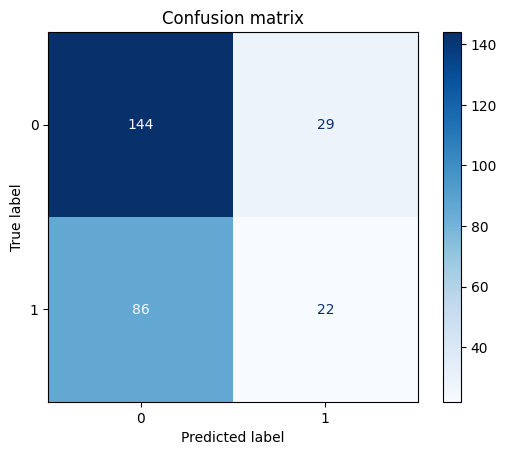

In [44]:
# Display confussion matrix
disp = ConfusionMatrixDisplay.from_estimator(
        gscv,
        X_test,
        y_test,
        cmap=plt.cm.Blues
    )
plt.title('Confusion matrix')
plt.show()

In [45]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.83      0.71       173
           1       0.43      0.20      0.28       108

    accuracy                           0.59       281
   macro avg       0.53      0.52      0.50       281
weighted avg       0.55      0.59      0.55       281



#### Evaluation: 

The precision ratio (TP/(TP+FP)) of label "1" answer the question: of all the times the model predicted "1" how often was it actually "1". Based on the classification report, the label "1" only has a precision ratio  is 0.43. The recall ratio (TP/(TP+FN)) of label "1" answer the Question: of all the labels that were actually "1," how many did the model catch? The label "1" has a recall ratio  if 0.28. Both ratio indicate the model is not good at predicting positive return. 

The F1-score (2 * (Precision * Recall) / (Precision + Recall))is the harmonic mean of precision and recall. It's a single score that is high only if both precision and recall are high. If either one is very low, the F1-score will also be low. It's the best all-around metric when you need to balance both precision and recall, and it's especially useful for imbalanced datasets. Here, as the recall ratio for label "1" is very small, so the f1-score is very small, incidating an imbalance between precision and recall ratio. 

The accuracy score ((TP + TN) / Total) shows the percentage of all predictions the model got right. For this model, the accuracy ratio is 0.59, which is above 0.5. This score is higher as the model have a much better predictability on label "0", with the precision ratio to be 0.63 and recall ratio to be 0.83.

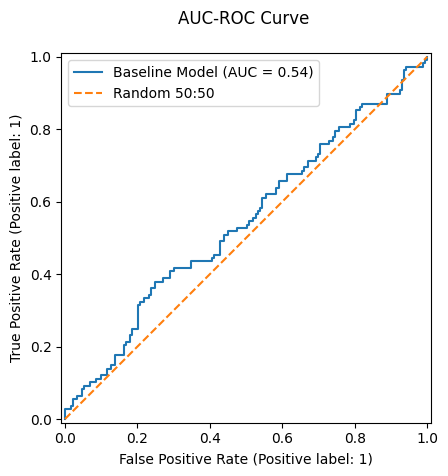

In [46]:
# Display ROC Curve
disp = RocCurveDisplay.from_estimator(
            gscv,
            X_test,
            y_test,
            name='Baseline Model')
plt.title("AUC-ROC Curve \n")
plt.plot([0,1],[0,1],linestyle="--", label='Random 50:50')
plt.legend()
plt.show()

#### Evaluation: 

##### ROC:
A ROC curve (which stands for Receiver Operating Characteristic) is a graph that shows how well a binary classification model can distinguish between two classes. It's one of the most important tools for evaluating a classifier because it's not based on a single, arbitrary threshold. It shows you the model's performance at all possible classification thresholds.

A ROC curve plots two key metrics against each other: True Positive Rate (TPR) on the y-axis and False Positive Rate (FPR) on the x-axis

TPR=(True Positives+False Negatives)/True Positives. A high TPR means your model is good at "catching" the positive cases.

FPR=(False Positives+True Negatives)/ False Positives. You want this number to be low. A low FPR means your model doesn't create many "false alarms."

The 45-degree diagnol line represents a model with no skill. This is what you'd get from random guessing. A model on this line is useless. The top-left corner gives the "perfect" model. It has a True Positive Rate of 1 (it catches 100% of the positive cases) and a False Positive Rate of 0 (it has 0% false alarms). This means the closer your model's curve "hugs" the top-left corner, the better it is. A good model will have a high TPR while maintaining a low FPR.

Here for my model, the curve is a little above the 45-degree line but still far from the top-left corner, which means my model has some prediction power, but not a lot. 

##### AUC:
AUC measures the entire two-dimensional area underneath the ROC curve.

Here's how to interpret the AUC score:

1.0 (Perfect): Your model is a perfect classifier. It has a threshold that can correctly classify 100% of your data.

0.5 (Failure): Your model has no skill at all. It's no better than random guessing (the diagonal line).

< 0.5 (Failure): Your model is performing worse than random. This usually means its predictions are just inverted (e.g., it's predicting "Spam" when it means "Not Spam").

The AUC is a powerful and popular metric because it evaluates the model across all thresholds, making it a robust measure of performance, especially on imbalanced datasets where a simple accuracy score can be very misleading.

For my model, the AUC is 0.54, which is slighly above 0.5, meaning my model have a little bit of prediction power but not much. 

# Step 5 Trading Strategy


In [51]:
# Subsume into a new dataframe
df2 = X.copy()                          
df2['Signal'] = gscv.predict(X)        

# Daily Returns - Benchmark return
df2['Returns'] = dailyReturn(Data.Close)

# Strategy Returns 
df2['Strategy'] =  df2['Returns'] * df2['Signal'].shift(1).fillna(0)  ## daily trade, close the position at EOD

# Localize index for pyfolio
df2.index = df2.index.tz_localize('utc')

# Check the output
df2

,LB7,GAP,RET,OC7,SPY_RET14,OC28,GAP28,MA_Ratio,Bollinger_Width,Signal,Returns,Strategy
Date,,,,,,,,,,,,
2020-03-13 00:00:00+00:00,38.113101,0.059037,0.036131,0.366099,-0.179955,0.052631,-0.004775,0.946019,0.268978,0,0.036131,0.000000
2020-03-16 00:00:00+00:00,36.549136,-0.128533,-0.068521,-0.125343,-0.265070,-0.035823,-0.009469,0.930991,0.309814,1,-0.068521,-0.000000
2020-03-17 00:00:00+00:00,36.485453,0.013699,0.041547,-0.243989,-0.208801,-0.076555,-0.009016,0.918324,0.327295,0,0.041547,0.041547
2020-03-18 00:00:00+00:00,35.365473,-0.051717,-0.050647,-0.280006,-0.214809,-0.079575,-0.010942,0.897074,0.353033,0,-0.050647,-0.000000
2020-03-19 00:00:00+00:00,34.110583,-0.010925,-0.069709,0.078083,-0.208476,0.006057,-0.011266,0.874955,0.393494,0,-0.069709,-0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-02 00:00:00+00:00,65.471390,-0.003744,-0.010235,0.095715,0.020574,0.123506,-0.000014,0.975342,0.029985,0,-0.010235,-0.000000
2025-10-03 00:00:00+00:00,65.438804,0.000000,0.008286,0.022857,0.015249,0.062041,-0.000004,0.976219,0.027354,0,0.008286,0.000000
2025-10-06 00:00:00+00:00,65.475501,-0.002401,-0.008286,-0.031429,0.020207,0.064982,-0.000147,0.976789,0.027337,0,-0.008286,-0.000000


Start date,2020-03-13
End date,2025-10-08
Total months,66
,Backtest
Annual return,33.609%
Cumulative returns,400.717%
Annual volatility,12.569%
Sharpe ratio,2.37
Calmar ratio,4.56
Stability,0.90
Max drawdown,-7.37%


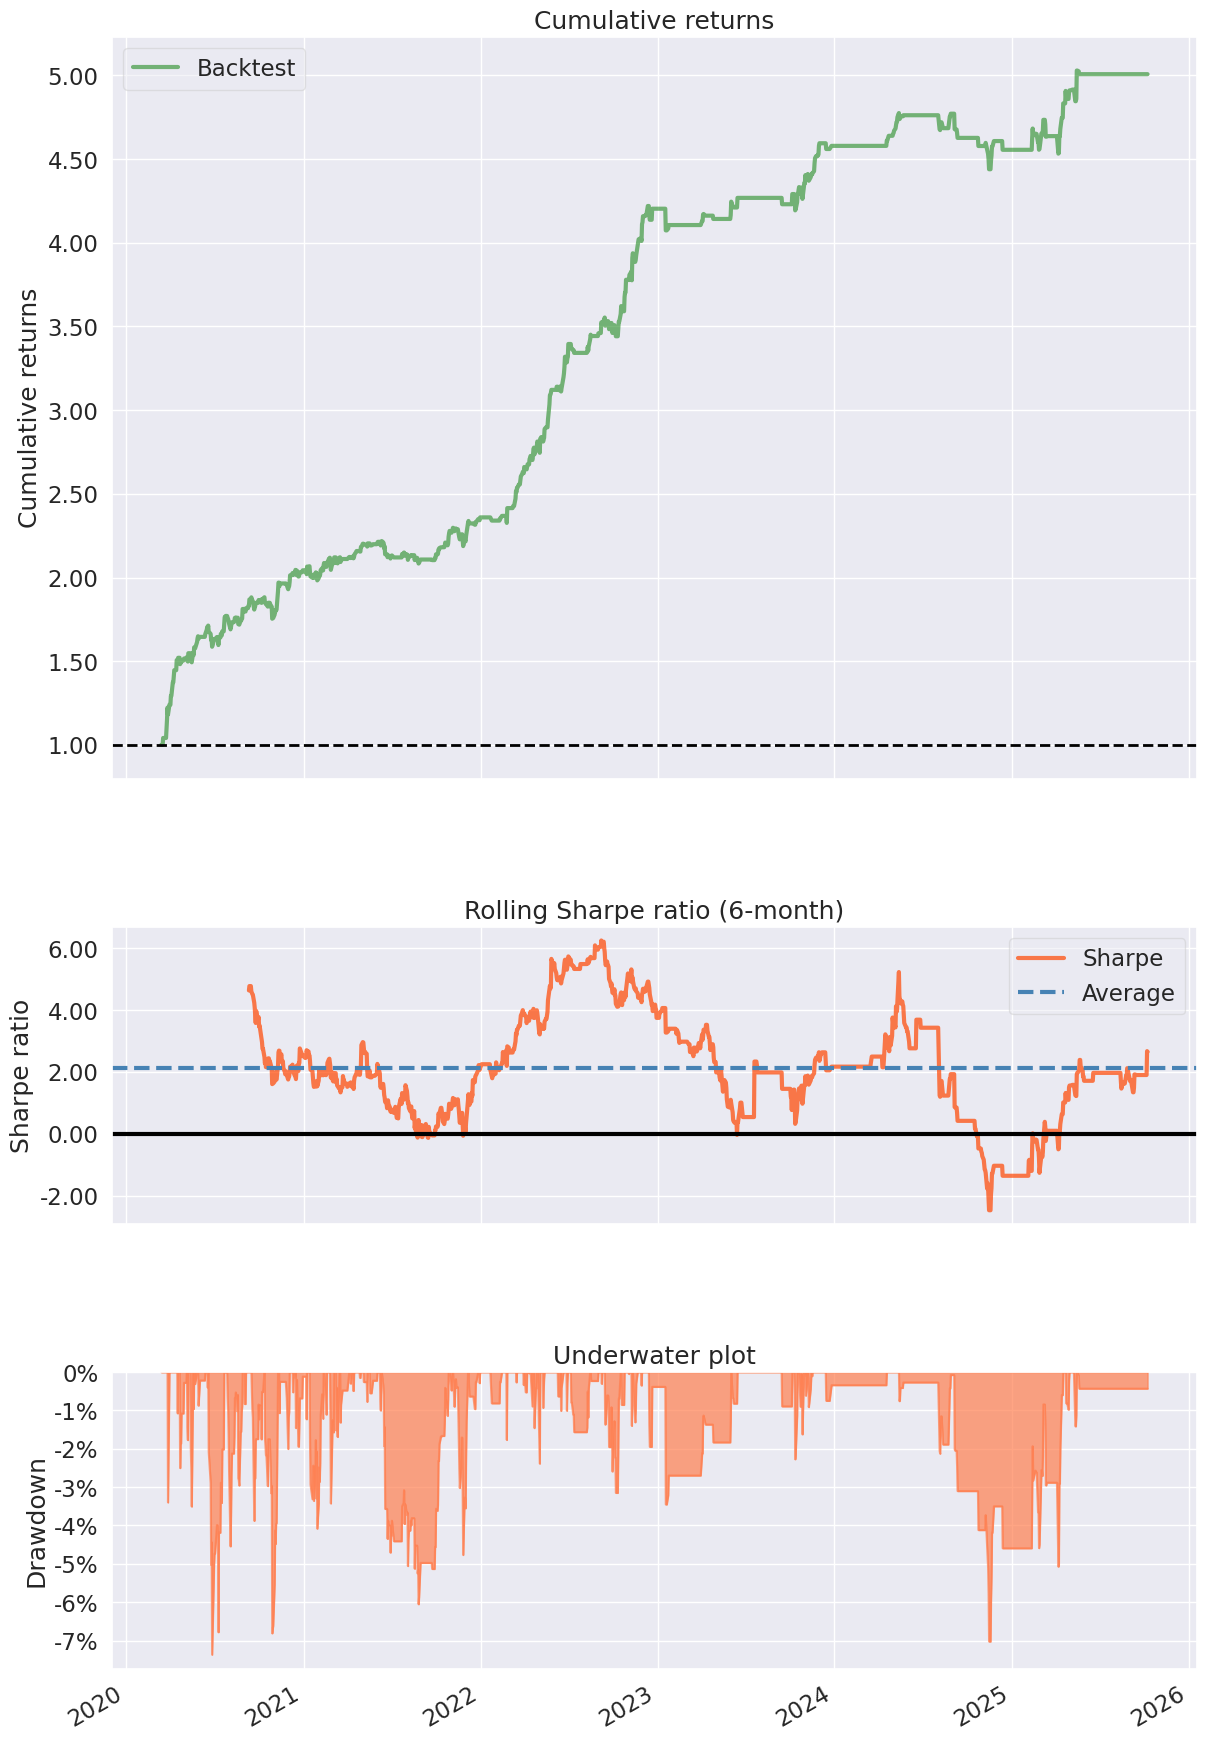

In [53]:
# Create Tear sheet using pyfolio for outsample - for X_test
pf.create_simple_tear_sheet(df2['Strategy'])

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,7.37,2020-06-18,2020-06-26,2020-07-21,24
1,7.03,2024-05-13,2024-11-15,2025-04-17,244
2,6.81,2020-10-12,2020-10-28,2020-11-09,21
3,6.05,2021-06-11,2021-08-26,2021-10-27,99
4,4.77,2021-11-05,2021-11-26,2021-12-06,22


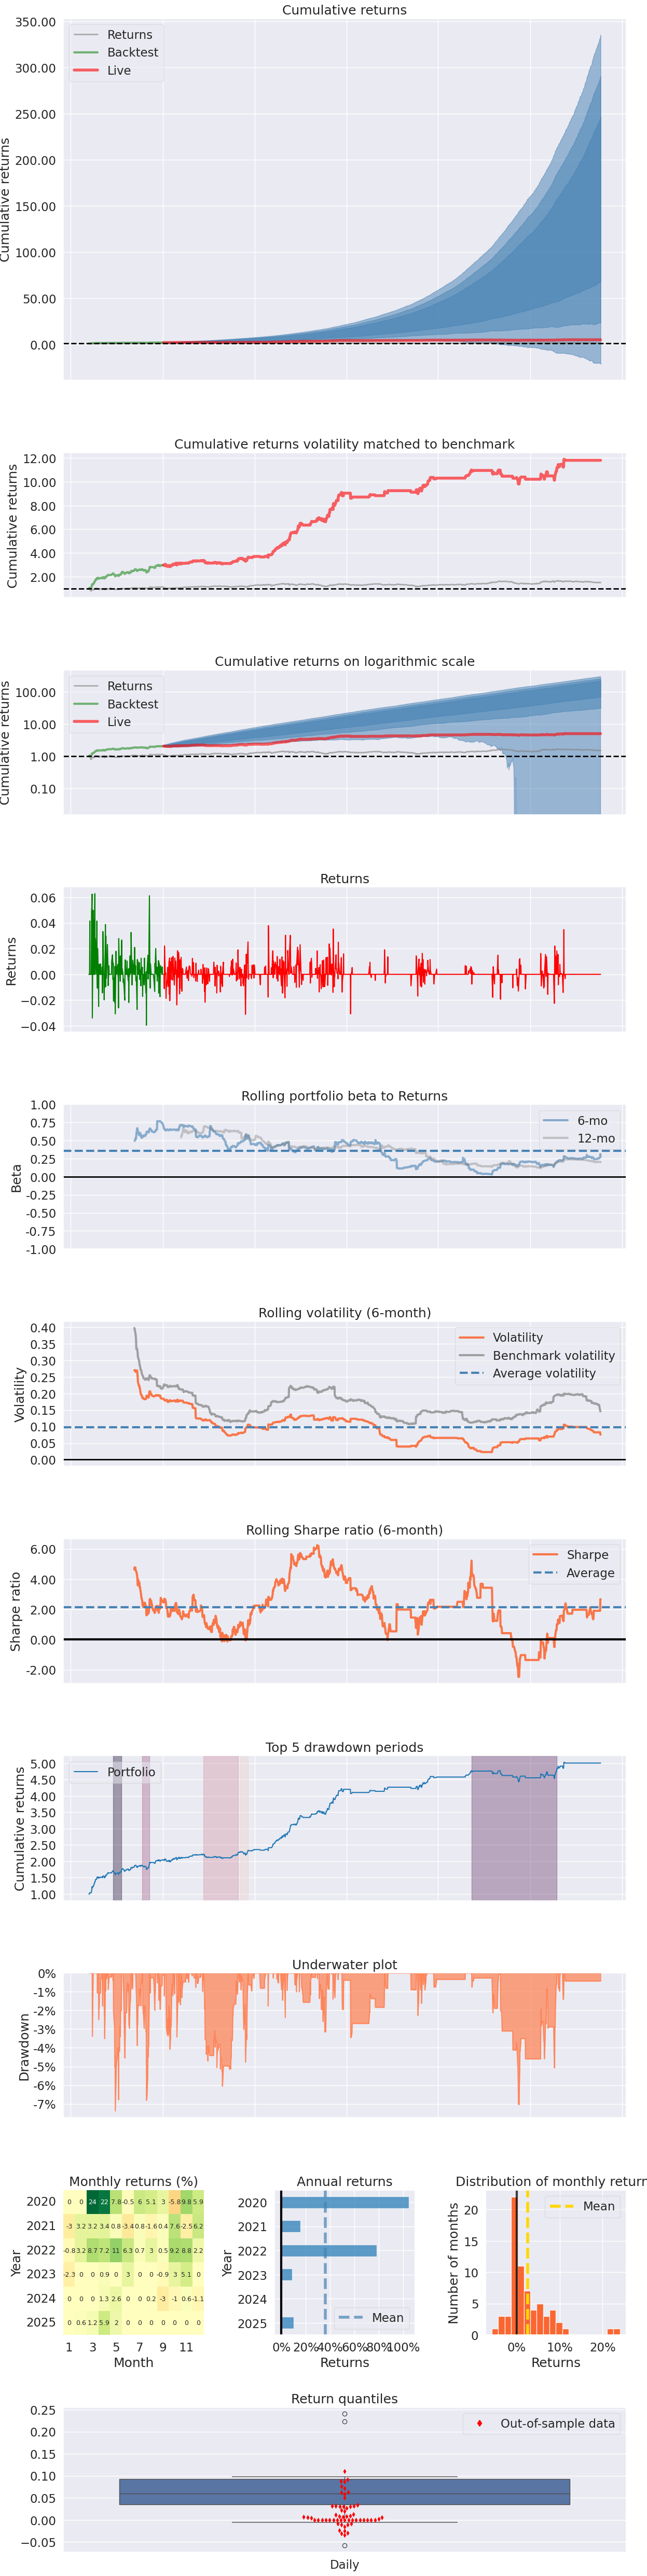

In [55]:
# Live start date from 
pf.create_returns_tear_sheet(df2['Strategy'], live_start_date='2021-01-01', benchmark_rets=df2['Returns'])


#### Evalutation
1. annual return: IS return much higher than OOS return, which means there might be some overfitting.
2. Cumulative returns: if look at All cumulative return, the value quadruple in 5 years.
3. Sharpe ratio: usually compare to 1. Larger than 1 means very good. Here the sharpe ratio is above 2, which means performance is very good.
4. Sortino ratio: return/downside risk. usually compare to 1. Larger than 1 means very good. Here the Sortino ratio is above 1, which means performance is very good.
5. Max drawdown: usually compare to -15%. smaller than -15% means good control. Here the max drawdown is only -7%, which means the control is good. 
6. Calmar ratio: annual return/max drawdown. usually compare to 0.5. larger than 0.5 means good. Here the Calmar ratio is much above 0.5, which means performance is very good. 
7. Skew: 2 means right skew. 
8. Kurtosis: much larger than 3, means absolutely high peak and fat tail. need to be careful about extreme events. 
9. Tail ratio: right tail(gain)/left tail(loss). Here we get 1.5. Larger than 1 means gain more than loss.
10. Alpha: here we get 0.3. Larger than 0 means there is alpha return.
11. Beta: here we get 0.42. Smaller than 1 means not very correlated with the market. 